In [1]:
import pandas as pd
import numpy as np
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
df = pd.read_csv("/kaggle/input/datasets/mohamedaln/merged-moffitt-boundaries-cleaned-v2/merged_moffitt_boundaries_cleaned_v2.csv", low_memory=False)

print(df.shape)
print(df.dtypes.value_counts())
print(list(df.columns))
df.head()

(32648, 168)
float64    159
object       8
int64        1
Name: count, dtype: int64
['Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'feature_uID', 'boundaryX', 'boundaryY', 'Ace2', 'Adora2a', 'Aldh1l1', 'Amigo2', 'Ano3', 'Aqp4', 'Ar', 'Arhgap36', 'Avpr1a', 'Avpr2', 'Baiap2', 'Bdnf', 'Bmp7', 'Brs3', 'Calcr', 'Cbln1', 'Cbln2', 'Cckar', 'Cckbr', 'Ccnd2', 'Cd24a', 'Cdkn1a', 'Cenpe', 'Chat', 'Coch', 'Col25a1', 'Cplx3', 'Cpne5', 'Creb3l1', 'Crhbp', 'Crhr1', 'Crhr2', 'Cspg5', 'Cxcl14', 'Cyp19a1', 'Cyp26a1', 'Cyr61', 'Dgkk', 'Ebf3', 'Egr2', 'Ermn', 'Esr1', 'Etv1', 'Fbxw13', 'Fezf1', 'Fn1', 'Fst', 'Gabra1', 'Gabrg1', 'Gad1', 'Galr1', 'Galr2', 'Gbx2', 'Gda', 'Gem', 'Gjc3', 'Glra3', 'Gpr165', 'Greb1', 'Grpr', 'Htr2c', 'Igf1r', 'Igf2r', 'Irs4', 'Isl1', 'Kiss1r', 'Klf4', 'Krt90', 'Lepr', 'Lmod1', 'Lpar1', 'Man1a', 'Mc4r', 'Mki67', 'Mlc1', 'Myh11', 'Ndnf', 'Ndrg1', 'Necab1', 'Nos1', 'Npas1', 'Npy1r', 'Npy2r', 'Ntng1', 'Ntsr1

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,feature_uID,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
0,9f29bd57-16a5-4b26-b9f5-37598809da9e,1,Female,Naive,0.26,-3209.578004,2633.153494,Inhibitory,I-6,9f29bd57-16a5-4b26-b9f5-37598809da9e,...,0.213939,0.000000,0.377907,0.049332,0.084898,0.008951,0.0,0.000000,0.0,0.000000
1,54434f3a-eba9-4aec-af35-c9d317ffa1d5,1,Female,Naive,0.26,-3202.682705,2608.803635,Inhibitory,I-9,54434f3a-eba9-4aec-af35-c9d317ffa1d5,...,1.250661,0.159618,0.211159,0.000000,0.087730,0.000000,0.0,0.000000,0.0,0.029419
2,fc52e122-5797-4f65-96ae-677e3b588eeb,1,Female,Naive,0.26,-3188.594070,2652.129395,Inhibitory,I-21,fc52e122-5797-4f65-96ae-677e3b588eeb,...,0.000000,0.000000,0.066380,0.000000,0.000000,0.095615,0.0,0.008855,0.0,0.000000
3,b4d760d2-7c35-4861-9f60-aeeb9b852f89,1,Female,Naive,0.26,-3155.099045,2604.352561,Inhibitory,I-9,b4d760d2-7c35-4861-9f60-aeeb9b852f89,...,0.032324,0.000000,0.340201,0.000000,0.003415,0.008947,0.0,0.000000,0.0,0.000000
4,e7de77bf-ad21-4265-b19b-af67541b42df,1,Female,Naive,0.26,-3125.241084,2624.485503,Inhibitory,I-9,e7de77bf-ad21-4265-b19b-af67541b42df,...,0.527074,0.078755,0.374770,0.000000,0.017975,0.001238,0.0,0.113817,0.0,0.000000


In [2]:
# Step 2) Minimal cleaning for ML
# - Removes redundant ID column, exact duplicate rows, and numeric columns that are all zeros.
# Step 2.1) Drop redundant ID column (we already know it's identical to Cell_ID)
if "feature_uID" in df.columns:
    df.drop(columns=["feature_uID"], inplace=True)

# Step 2.2) Drop exact duplicate rows
df.drop_duplicates(inplace=True)

# Step 2.3) Drop all-zero numeric columns (drops Fos too, but only if it's truly all zeros)
num_cols = df.select_dtypes(include=[np.number]).columns
zero_cols = [c for c in num_cols if df[c].notna().any() and df[c].dropna().eq(0).all()]
if zero_cols:
    df.drop(columns=zero_cols, inplace=True)
# Step 2.3b) Drop all-NaN columns (no signal for ML)
all_nan_cols = [c for c in df.columns if df[c].isna().all()]
if all_nan_cols:
    df.drop(columns=all_nan_cols, inplace=True)

print("Dropped all-NaN columns:", all_nan_cols)
# Step 2.4) Save checkpoint
out_step2 = "/kaggle/working/moffitt_clean_step2.csv"
df.to_csv(out_step2, index=False)

print("Shape after Step 2:", df.shape)
print("Dropped all-zero numeric columns:", zero_cols)
print("Saved:", out_step2)

Dropped all-NaN columns: ['Fos']
Shape after Step 2: (32648, 166)
Dropped all-zero numeric columns: []
Saved: /kaggle/working/moffitt_clean_step2.csv


In [3]:
# Step 3) Extract thesis shape features from boundary polygons
# - Computes: area, perimeter, circularity, aspect ratio, vertex count (per cell) from boundaryX/boundaryY.
# Step 3.1) Basic guards + clean old outputs if they exist
# - Ensures boundary columns exist and avoids duplicate/old shape columns.
required = ["boundaryX", "boundaryY"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

shape_cols = [
    "shape_area",
    "shape_perimeter",
    "shape_circularity",
    "shape_aspect_ratio",
    "shape_vertex_count",
]
# Step 3.2) Parse boundary strings into float arrays
# - Robust parsing: extracts all numbers from strings like "[1,2,3]" or "1 2 3".
_num_pat = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def to_float_array(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return np.asarray(v, dtype=np.float64)
    if pd.isna(v):
        return None
    nums = _num_pat.findall(str(v))
    if not nums:
        return None
    return np.asarray(nums, dtype=np.float64)

# Step 3.3) Compute the 5 features for one polygon
# - Returns NaNs if the polygon is invalid (mismatch, too few points, degenerate bbox, etc.).
def polygon_shape_features(bx, by):
    x = to_float_array(bx)
    y = to_float_array(by)

    if x is None or y is None or len(x) != len(y) or len(x) < 3:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    m = ~(np.isnan(x) | np.isnan(y))
    x, y = x[m], y[m]
    if len(x) < 3:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    # Remove repeated closing vertex if present
    if np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1]):
        x, y = x[:-1], y[:-1]
    if len(x) < 3:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    vertex_count = float(len(x))

    # Area (shoelace)
    area = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    # Perimeter
    dx = np.diff(np.r_[x, x[0]])
    dy = np.diff(np.r_[y, y[0]])
    perimeter = np.sqrt(dx * dx + dy * dy).sum()

    # Circularity
    circularity = (4.0 * np.pi * area / (perimeter * perimeter)) if perimeter > 0 else np.nan

    # Bounding-box aspect ratio
    w = x.max() - x.min()
    h = y.max() - y.min()
    aspect_ratio = (w / h) if h > 0 else np.nan

    return (area, perimeter, circularity, aspect_ratio, vertex_count)

# Step 3.4) Run extraction over all rows (fast + progress bar)
# - Builds a 5-column feature matrix aligned with df rows.
n = len(df)
feat = np.full((n, 5), np.nan, dtype=np.float32)

for i, (bx, by) in enumerate(
    tqdm(zip(df["boundaryX"].values, df["boundaryY"].values), total=n, desc="Step 3: thesis shape features")
):
    feat[i, :] = polygon_shape_features(bx, by)

shape_df = pd.DataFrame(feat, columns=shape_cols)

# Step 3.5) Attach + QC + save
# - Adds the features to df, reports invalid rows, and saves a clean checkpoint.
df = pd.concat([df.reset_index(drop=True), shape_df], axis=1)

invalid = int(df[shape_cols].isna().any(axis=1).sum())
print("Invalid rows (any NaN in thesis shape features):", invalid, "/", n)
print("Shape after Step 3:", df.shape)

out_step3 = "/kaggle/working/moffitt_clean_step3_thesis_shape.csv"
df.to_csv(out_step3, index=False)
print("Saved:", out_step3)

Step 3: thesis shape features:   0%|          | 0/32648 [00:00<?, ?it/s]

Invalid rows (any NaN in thesis shape features): 259 / 32648
Shape after Step 3: (32648, 171)
Saved: /kaggle/working/moffitt_clean_step3_thesis_shape.csv


In [4]:
# Step 4) Export ML-ready datasets (Shape / Genes / Shape+Genes)
# - Uses Cell_class as 15-class:contentReference[oaicite:19]{index=19}d shape rows, saves 3 CSVs (with Cell_ID kept for alignment).
# Step 4.1) Config
label_col = "Cell_class"
shape_cols = ["shape_area", "shape_perimeter", "shape_circularity", "shape_aspect_ratio", "shape_vertex_count"]
meta_numeric = {"Animal_ID", "Bregma", "Centroid_X", "Centroid_Y"}
id_cols = [c for c in ["Cell_ID", "Animal_ID"] if c in df.columns]

# Step 4.2) Drop invalid shape rows + save them
invalid_mask = df[shape_cols].isna().any(axis=1)

invalid_path = "/kaggle/working/moffitt_invalid_shape_rows.csv"
df.loc[invalid_mask, id_cols + [label_col, "boundaryX", "boundaryY"] + shape_cols].to_csv(invalid_path, index=False)

df_ml = df.loc[~invalid_mask].copy()

# Step 4.3) Enforce 15 classes
n_classes = int(df_ml[label_col].nunique(dropna=True))
print("Target classes (Cell_class):", n_classes)
if n_classes != 15:
    raise ValueError(f"Expected 15 classes in {label_col}, got {n_classes}")

# Step 4.4) Remove raw boundaries from ML inputs
df_ml.drop(columns=["boundaryX", "boundaryY"], inplace=True, errors="ignore")

# Step 4.5) Gene columns = numeric columns excluding metadata + shape
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in numeric_cols if (c not in meta_numeric) and (c not in shape_cols)]

print("Dropped invalid rows:", int(invalid_mask.sum()))
print("Rows kept:", len(df_ml))
print("Gene columns:", len(gene_cols))
print("Saved invalid rows:", invalid_path)

# Step 4.6) Save the 3 thesis datasets (keep Cell_ID/Animal_ID for alignment checks)
df_model1 = df_ml[id_cols + [label_col] + shape_cols].copy()
df_model2 = df_ml[id_cols + [label_col] + gene_cols].copy()
df_model3 = df_ml[id_cols + [label_col] + shape_cols + gene_cols].copy()

p1 = "/kaggle/working/moffitt_model1_shape_only.csv"
p2 = "/kaggle/working/moffitt_model2_genes_only.csv"
p3 = "/kaggle/working/moffitt_model3_shape_plus_genes.csv"

df_model1.to_csv(p1, index=False)
df_model2.to_csv(p2, index=False)
df_model3.to_csv(p3, index=False)

print("Saved:", p1)
print("Saved:", p2)
print("Saved:", p3)

Target classes (Cell_class): 15
Dropped invalid rows: 259
Rows kept: 32389
Gene columns: 155
Saved invalid rows: /kaggle/working/moffitt_invalid_shape_rows.csv
Saved: /kaggle/working/moffitt_model1_shape_only.csv
Saved: /kaggle/working/moffitt_model2_genes_only.csv
Saved: /kaggle/working/moffitt_model3_shape_plus_genes.csv



Class counts (post invalid-shape drop):
Cell_class
Inhibitory       11250
Excitatory        5315
Astrocyte         4780
OD Mature 2       3219
Endothelial 1     2358
OD Immature 1     1287
Ependymal         1032
Microglia          880
Endothelial 3      792
OD Mature 1        533
Pericytes          343
Endothelial 2      329
OD Mature 4        179
OD Immature 2       59
OD Mature 3         33

Keeping top-8 classes: ['Inhibitory', 'Excitatory', 'Astrocyte', 'OD Mature 2', 'Endothelial 1', 'OD Immature 1', 'Ependymal', 'Microglia']

Counts in kept subset (before balance):
Cell_class
Inhibitory       11250
Excitatory        5315
Astrocyte         4780
OD Mature 2       3219
Endothelial 1     2358
OD Immature 1     1287
Ependymal         1032
Microglia          880

Subset shapes:
 df_shape: (30121, 8) | df_genes: (30121, 158) | df_both: (30121, 163)

Model 1 — Shape Only
 Accuracy : 0.326
 Macro-F1 : 0.1505


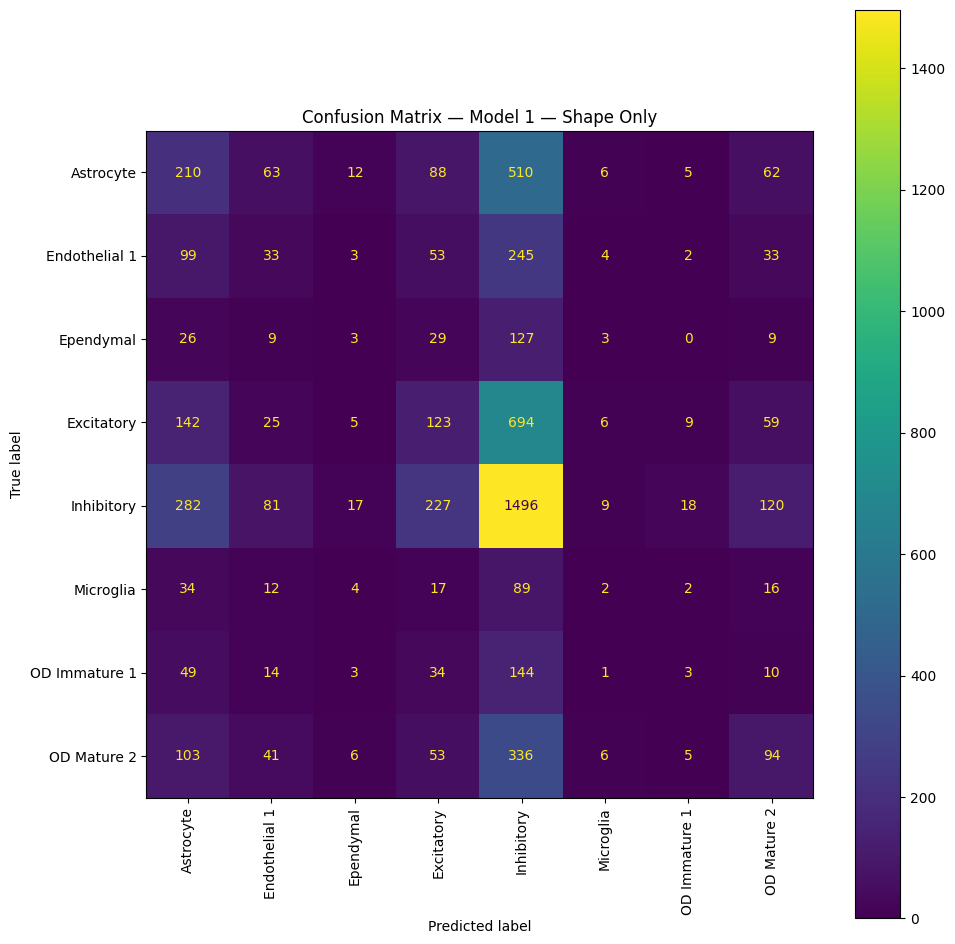

 Top 5 MDI features (impurity-based):
shape_circularity     0.238881
shape_aspect_ratio    0.232105
shape_perimeter       0.227073
shape_area            0.225203
shape_vertex_count    0.076738
dtype: float64
 Top 5 permutation importances (test, f1_macro):
shape_perimeter       0.035987
shape_area            0.032612
shape_circularity     0.029609
shape_vertex_count    0.013293
shape_aspect_ratio    0.004920
dtype: float64

Model 2 — Genes Only
 Accuracy : 0.9469
 Macro-F1 : 0.9538


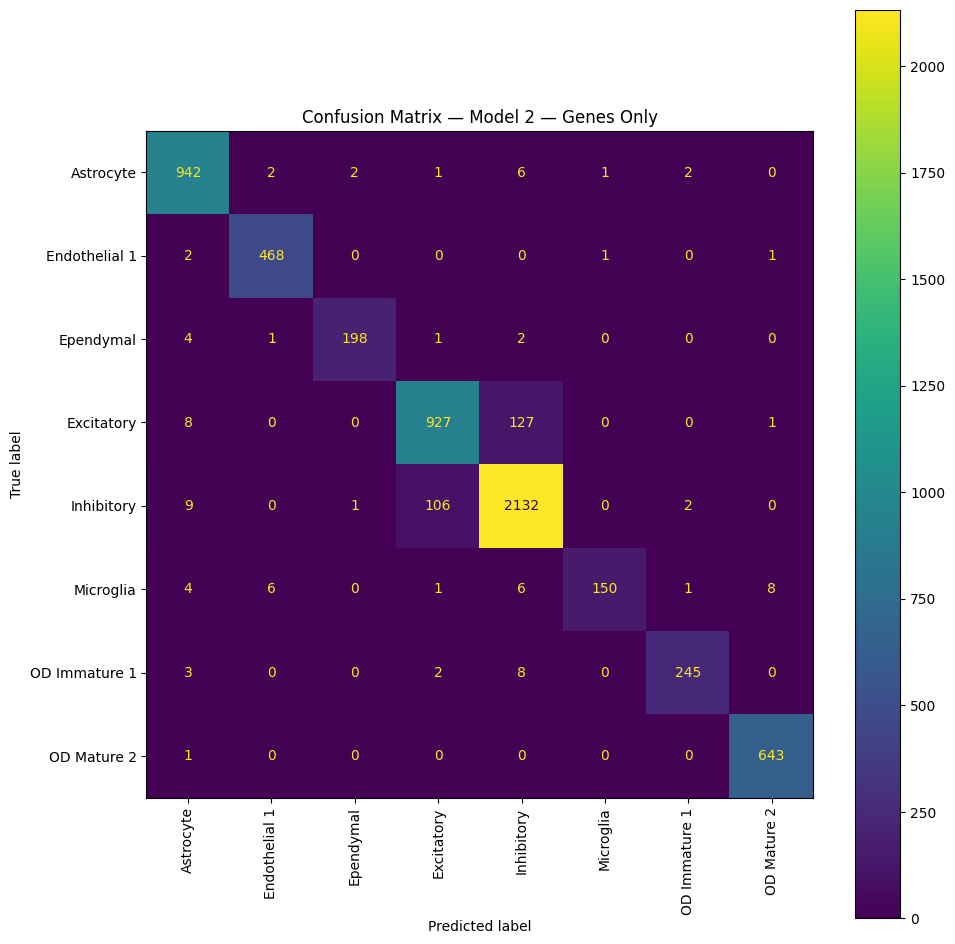


Model 3 — Shape + Genes
 Accuracy : 0.9482
 Macro-F1 : 0.9564


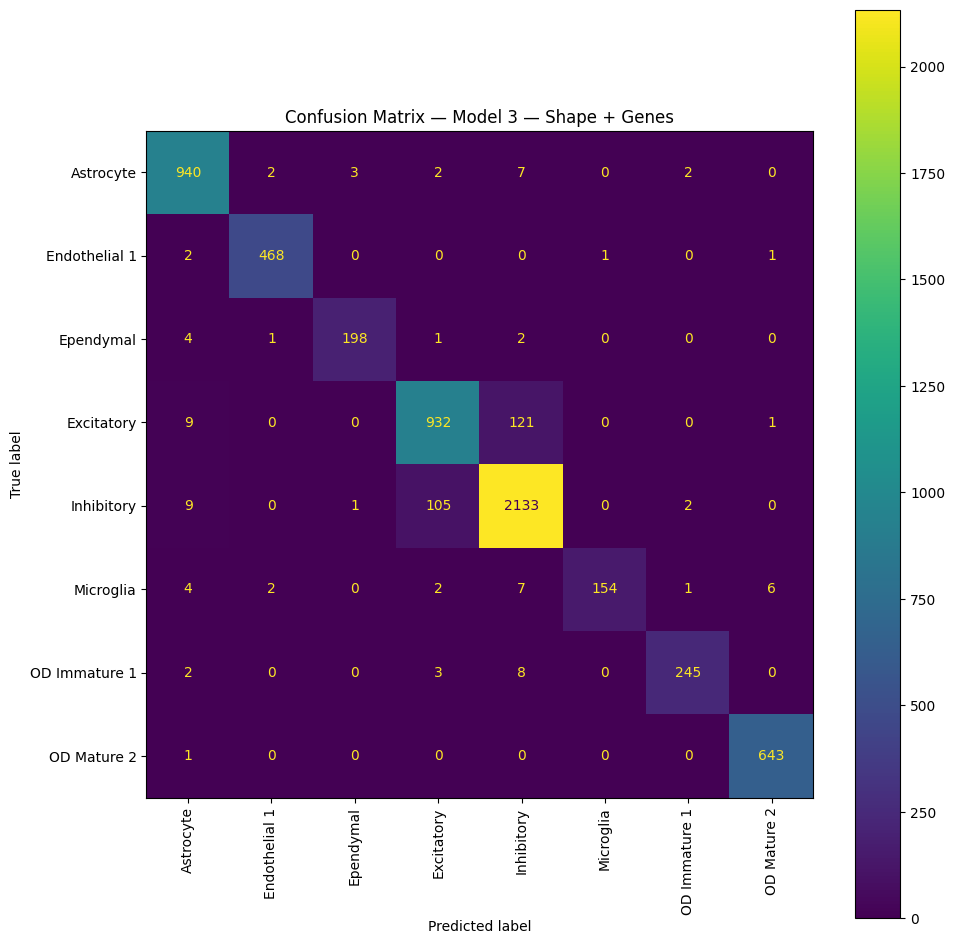

 Top 20 MDI features (impurity-based):
Selplg     0.069498
Pdgfra     0.053401
Slc17a6    0.042176
Slco1a4    0.040334
Cd24a      0.035645
Sgk1       0.033809
Mlc1       0.032402
Gjc3       0.032362
Gad1       0.031794
Aldh1l1    0.030937
Fn1        0.029260
Ermn       0.028931
Ttyh2      0.028446
Aqp4       0.026876
Ndrg1      0.026155
Cspg5      0.026091
Igf1r      0.021737
Traf4      0.020810
Nnat       0.019368
Sox8       0.017920
dtype: float64
 Top 20 permutation importances (test, f1_macro):
Selplg             0.116626
Slc17a6            0.039317
Pdgfra             0.036490
Gad1               0.010656
Cd24a              0.008170
Mlc1               0.004808
Slco1a4            0.004062
Aldh1l1            0.003786
Traf4              0.003340
Cspg5              0.002914
Fn1                0.002742
Gjc3               0.002685
Aqp4               0.002116
Sema4d             0.001944
Cxcl14             0.001379
Sox8               0.001335
Cbln2              0.001274
Cbln1              0

In [7]:
# Step 5) Train and evaluate the 3 thesis models (Random Forest)
# - Reuses one stratified split across Shape / Genes / Shape+Genes, and checks Cell_ID alignment first

# Step 5.1) Load datasets
label_col = "Cell_class"
id_cols = ["Cell_ID", "Animal_ID"]  # will drop if missing

p_shape = "/kaggle/working/moffitt_model1_shape_only.csv"
p_genes = "/kaggle/working/moffitt_model2_genes_only.csv"
p_both  = "/kaggle/working/moffitt_model3_shape_plus_genes.csv"

df_shape = pd.read_csv(p_shape)
df_genes = pd.read_csv(p_genes)
df_both  = pd.read_csv(p_both)

# Step 5.2) Hard check: same rows across all 3 CSVs (by Cell_ID)
if all("Cell_ID" in d.columns for d in [df_shape, df_genes, df_both]):
    if not (df_shape["Cell_ID"].tolist() == df_genes["Cell_ID"].tolist() == df_both["Cell_ID"].tolist()):
        raise ValueError("Row order mismatch across datasets (Cell_ID not aligned). Rebuild Step 4 outputs.")
else:
    print("Warning: Cell_ID not found in all datasets; cannot verify alignment.")

# -------------------------------------------------------------------
# Step 5.2b) OPTIONAL: restrict to top-K classes, and optionally balance
# -------------------------------------------------------------------
# Always print class counts so you can decide.
class_counts = df_shape[label_col].value_counts()
print("\nClass counts (post invalid-shape drop):")
print(class_counts.to_string())

USE_SUBSET = True   # set False to run full 15-class experiment
K = 8              # number of top-count classes to keep
BALANCE = False      # recommended for fair comparison across classes

if USE_SUBSET:
    keep_classes = class_counts.head(K).index.tolist()
    print(f"\nKeeping top-{K} classes:", keep_classes)

    mask = df_shape[label_col].isin(keep_classes).to_numpy()

    df_shape_sub = df_shape.iloc[np.where(mask)[0]].copy()
    df_genes_sub = df_genes.iloc[np.where(mask)[0]].copy()
    df_both_sub  = df_both.iloc[np.where(mask)[0]].copy()

    print("\nCounts in kept subset (before balance):")
    print(df_shape_sub[label_col].value_counts().to_string())

    if BALANCE:
        vc = df_shape_sub[label_col].value_counts()
        min_n = int(vc.min())
        if min_n < 2:
            raise ValueError(f"Cannot stratify/train with min class count < 2. min_n={min_n}. Adjust K/BALANCE.")

        keep_idx = (
            df_shape_sub.groupby(label_col, group_keys=False, sort=True)
                        .apply(lambda x: x.sample(n=min_n, random_state=42))
                        .index
        )

        # Keep deterministic row order across all three datasets
        keep_idx = np.sort(keep_idx.to_numpy())

        df_shape_sub = df_shape.loc[keep_idx].copy()
        df_genes_sub = df_genes.loc[keep_idx].copy()
        df_both_sub  = df_both.loc[keep_idx].copy()

        print(f"\nBalanced to {min_n} per class:")
        print(df_shape_sub[label_col].value_counts().to_string())

    # Re-check alignment after subsetting/balancing
    if all("Cell_ID" in d.columns for d in [df_shape_sub, df_genes_sub, df_both_sub]):
        if not (df_shape_sub["Cell_ID"].tolist() == df_genes_sub["Cell_ID"].tolist() == df_both_sub["Cell_ID"].tolist()):
            raise ValueError("Post-subset row order mismatch across datasets (Cell_ID not aligned).")

    # Overwrite frames used downstream (Step 5.3+)
    df_shape = df_shape_sub.reset_index(drop=True)
    df_genes = df_genes_sub.reset_index(drop=True)
    df_both  = df_both_sub.reset_index(drop=True)

    print("\nSubset shapes:")
    print(" df_shape:", df_shape.shape, "| df_genes:", df_genes.shape, "| df_both:", df_both.shape)

# Step 5.3) Build ONE stratified split index
y = df_shape[label_col].astype(str)
idx = np.arange(len(df_shape))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

# Use consistent label ordering across all models
labels_sorted_global = sorted(y.unique())

# Step 5.4) Fit/eval helper
def fit_eval_rf(df_in: pd.DataFrame, name: str, top_k: int = 20, perm_repeats: int = 5):
    drop_cols = [label_col] + [c for c in id_cols if c in df_in.columns]
    X = df_in.drop(columns=drop_cols)
    y_local = df_in[label_col].astype(str)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_local.iloc[train_idx], y_local.iloc[test_idx]

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    print(f"\n{name}")
    print(" Accuracy :", round(acc, 4))
    print(" Macro-F1 :", round(f1m, 4))

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        labels=labels_sorted_global,
        xticks_rotation=90,
        ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    # (A) Impurity-based importance (MDI)
    rf = model.named_steps["rf"]
    mdi_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    # (B) Permutation importance (test set, f1_macro)
    perm_imp = None
    if top_k and top_k > 0:
        print(f" Top {top_k} MDI features (impurity-based):")
        print(mdi_imp.head(top_k))

        perm = permutation_importance(
            model, X_test, y_test,
            n_repeats=perm_repeats,
            random_state=42,
            n_jobs=-1,
            scoring="f1_macro"
        )
        perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

        print(f" Top {top_k} permutation importances (test, f1_macro):")
        print(perm_imp.head(top_k))

    return {
        "accuracy": acc,
        "macro_f1": f1m,
        "mdi_importances": mdi_imp,
        "perm_importances": perm_imp,
        "model": model
    }

# Step 5.5) Train the 3 models
res1 = fit_eval_rf(df_shape, "Model 1 — Shape Only", top_k=5,  perm_repeats=5)
res2 = fit_eval_rf(df_genes, "Model 2 — Genes Only", top_k=0,  perm_repeats=5)   # skip importance to save time
res3 = fit_eval_rf(df_both,  "Model 3 — Shape + Genes", top_k=20, perm_repeats=5)

# Step 5.6) Save metrics summary
summary = pd.DataFrame([
    {"model": "shape_only",       "accuracy": res1["accuracy"], "macro_f1": res1["macro_f1"]},
    {"model": "genes_only",       "accuracy": res2["accuracy"], "macro_f1": res2["macro_f1"]},
    {"model": "shape_plus_genes", "accuracy": res3["accuracy"], "macro_f1": res3["macro_f1"]},
]).sort_values("model")

out_metrics = "/kaggle/working/moffitt_rf_metrics_summary.csv"
summary.to_csv(out_metrics, index=False)

print("\nSaved metrics summary:", out_metrics)
print(summary)

In [6]:
# Step 6) Interactive prediction — test any cell from the test set

def test_prediction(sample_idx=0):
    drop_cols_shape = [label_col] + [c for c in id_cols if c in df_shape.columns]
    drop_cols_genes = [label_col] + [c for c in id_cols if c in df_genes.columns]
    drop_cols_both  = [label_col] + [c for c in id_cols if c in df_both.columns]

    X_shape = df_shape.drop(columns=drop_cols_shape)
    X_genes = df_genes.drop(columns=drop_cols_genes)
    X_both  = df_both.drop(columns=drop_cols_both)
    y_local = df_shape[label_col].astype(str)

    true_label = y_local.iloc[test_idx[sample_idx]]

    models_list = [
        ("Shape Only",    X_shape, res1["model"]),
        ("Genes Only",    X_genes, res2["model"]),
        ("Shape + Genes", X_both,  res3["model"]),
    ]

    print(f"\n{'='*50}")
    print(f"Test cell #{sample_idx}  (dataset row {test_idx[sample_idx]})")
    print(f"True label: {true_label}")
    print(f"Cell_ID: {df_shape.iloc[test_idx[sample_idx]]['Cell_ID']}")
    print(f"{'='*50}")

    for name, X, trained_model in models_list:
        row   = X.iloc[[test_idx[sample_idx]]]
        pred  = trained_model.predict(row)[0]
        proba = trained_model.predict_proba(row)[0]
        top3  = sorted(zip(trained_model.classes_, proba), key=lambda x: -x[1])[:3]
        top3  = [(c, round(p, 3)) for c, p in top3]
        status = "✓" if pred == true_label else "✗"
        print(f"\n[{name}]  {status} Predicted: {pred}")
        print(f"  Top-3: {top3}")

# Change sample_idx to test different cells (0 to 6477)
test_prediction(sample_idx=465)


Test cell #465  (dataset row 842)
True label: Endothelial 1
Cell_ID: cc784fca-fa64-4570-ab21-c3225140a512

[Shape Only]  ✗ Predicted: OD Mature 2
  Top-3: [('OD Mature 2', np.float64(0.482)), ('Microglia', np.float64(0.175)), ('Endothelial 1', np.float64(0.112))]

[Genes Only]  ✓ Predicted: Endothelial 1
  Top-3: [('Endothelial 1', np.float64(0.935)), ('Microglia', np.float64(0.03)), ('Inhibitory', np.float64(0.012))]

[Shape + Genes]  ✓ Predicted: Endothelial 1
  Top-3: [('Endothelial 1', np.float64(0.945)), ('Microglia', np.float64(0.018)), ('Inhibitory', np.float64(0.01))]
